## 🇧🇷 Brazilian Grand Prix | 2025

In this notebook we focus on debriefing the Brazilian GP, 2025. I am currently ironing out my high-level API and ingridients that compose the recipe of a race debrief and will continue to evolve over the next few notebooks.

### Debrief Recipe (4 Pillars)
- Car Setup and Circuit Characteristics corelation.
- Car Dynamics and Management Delta.
- Tyre Degradation Coefficients.
- Attention Flags for best Car and Driving Style (wrt Telemetry; if available).

### Notebook Configurations

In [1]:
from pathlib import Path
import sys


# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
CACHE_PATH = F1_PATH / "cache"

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

### Imports

In [2]:
# FastF1 Dependencies
import fastf1
from fastf1.core import Laps

# Visualisation Dependencies
from plotly.offline import init_notebook_mode

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Codebase Dependencies
from src.custom import CustomSession
from src.data import DataUtils
from src.pipeline import Pipeline
from src.plotting import Plotting

# Enabling Notebook Rendering for Plotly
init_notebook_mode(connected=True)

### Accessing the Specific Event and Sessions

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
brazil_2025 = fastf1.get_event(
    year=2025,
    gp="brazil",
    backend="fastf1"
)
print(brazil_2025)

RoundNumber                                                         21
Country                                                         Brazil
Location                                                     São Paulo
OfficialEventName    FORMULA 1 MSC CRUISES GRANDE PRÊMIO DE SÃO PAU...
EventDate                                          2025-11-09 00:00:00
EventName                                         São Paulo Grand Prix
EventFormat                                          sprint_qualifying
Session1                                                    Practice 1
Session1Date                                 2025-11-07 11:30:00-03:00
Session1DateUtc                                    2025-11-07 14:30:00
Session2                                             Sprint Qualifying
Session2Date                                 2025-11-07 15:30:00-03:00
Session2DateUtc                                    2025-11-07 18:30:00
Session3                                                        Sprint
Sessio

### Source Dependency Instances

In [4]:
# Data Handler: Loading and Storing Data from FastF1
data_handle = DataUtils(race_event=brazil_2025, cache_dir=str(CACHE_PATH))

# Data Pipeline: Transforming Data
data_pipeline = Pipeline()

# Plot Handler: Plotting Categorical, Joint, Marginal Distributions and Telemetry Traces
plot_handle = Plotting()

### Loading the Data for the Event

In [5]:
brazil_quali, brazil_race = data_handle.load_data()
print(brazil_quali)

core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 5
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 5)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '16', '81', '6', '63', '30', '87', '10', '27', '14', '23', '44', 

2025 Season Round 21: São Paulo Grand Prix - Qualifying


### CustomSession objects for each FastF1 Session

In [6]:
# Accessing the different data streams for each session
qualifying_session = CustomSession(session=brazil_quali)
race_session = CustomSession(session=brazil_race)

### Data Cleaning and Segregation

**Accessing the top 5 drivers for each of the sessions**

In [7]:
top_5_drivers_in_race = race_session.results.iloc[:5]["DriverNumber"]
print("Top 5 Drivers in the Race:")
print(top_5_drivers_in_race)

top_5_drivers_in_quali = qualifying_session.results.iloc[:5]["DriverNumber"]
print("\nTop 5 Drivers in the Qualifying:")
print(top_5_drivers_in_quali)

Top 5 Drivers in the Race:
4      4
12    12
1      1
63    63
81    81
Name: DriverNumber, dtype: object

Top 5 Drivers in the Qualifying:
4      4
12    12
16    16
81    81
6      6
Name: DriverNumber, dtype: object


**Picking only the quick laps from the sessions for the top drivers (in the race)**<br><br>

⚠️ *As much as Will Buxton and DTS have gotten to me the reasoning is straight-forward points arent awarded for qualifying and hence all the analysis is done based on the results of the race*

✅ `However a separate Quali Lap Telemetry based dominance will also be provided in the analysis`

In [8]:
race_fast_laps = (
    race_session.laps
    .pick_drivers(identifiers=top_5_drivers_in_race)  
    .pick_quicklaps()
)

quali_fast_laps_by_quali = (
    qualifying_session.laps
    .pick_drivers(identifiers=top_5_drivers_in_quali)  
    .pick_quicklaps()
)

q1_laps, _, q3_laps = qualifying_session.laps.split_qualifying_sessions()
assert isinstance(q1_laps, Laps)

quali_fast_laps_by_race = (
    q1_laps
    .pick_drivers(identifiers=top_5_drivers_in_race)
    .pick_quicklaps()
)
quali_fast_laps_by_race.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
1,0 days 00:23:46.304000,NOR,4,0 days 00:01:10.404000,2.0,1.0,NaT,NaT,0 days 00:00:18.229000,0 days 00:00:36.070000,...,True,McLaren,0 days 00:22:35.900000,2025-11-08 18:08:27.336,1,NaN,False,,False,True
4,0 days 00:28:44.927000,NOR,4,0 days 00:01:10.249000,5.0,1.0,NaT,NaT,0 days 00:00:18.149000,0 days 00:00:36.079000,...,True,McLaren,0 days 00:27:34.678000,2025-11-08 18:13:26.114,1,NaN,False,,False,True
7,0 days 00:35:17.456000,NOR,4,0 days 00:01:09.656000,8.0,2.0,NaT,NaT,0 days 00:00:18.027000,0 days 00:00:35.681000,...,True,McLaren,0 days 00:34:07.800000,2025-11-08 18:19:59.236,1,NaN,False,,False,True
22,0 days 00:27:26.603000,ANT,12,0 days 00:01:10.192000,2.0,1.0,NaT,NaT,0 days 00:00:18.267000,0 days 00:00:35.837000,...,True,Mercedes,0 days 00:26:16.411000,2025-11-08 18:12:07.847,1,NaN,False,,False,True
60,0 days 00:22:44.664000,PIA,81,0 days 00:01:11.845000,2.0,1.0,NaT,NaT,0 days 00:00:19.531000,0 days 00:00:36.158000,...,False,McLaren,0 days 00:21:32.819000,2025-11-08 18:07:24.255,1,NaN,False,,False,True


**Segregating the Telemetry among Mini-Sessions**<br><br>
⚠️ *Telemetry only available for Qualifying*

In [9]:
assert isinstance(q1_laps, Laps)
assert isinstance(q3_laps, Laps)

# Lookup tables for the quick-lap driven telemetry
q1_telemetry_digest, q3_telemetry_digest = {}, {}

# Iterating through the top 5 drivers to access telemetetry from Qualifying
for driver_number in top_5_drivers_in_quali:
    q1_telemetry = (
        q1_laps.pick_drivers(identifiers=driver_number)
        .pick_fastest()
        .get_car_data()  # type: ignore
        .add_differential_distance()  # Delta Distance covered between two samples
        .add_distance()  # Cumulative Distance covered from first sample
    )
    q1_telemetry_digest[driver_number] = q1_telemetry

    q3_telemetry = (
        q3_laps.pick_drivers(identifiers=driver_number)
        .pick_fastest()  
        .get_car_data()  # type: ignore
        .add_differential_distance()
        .add_distance()
    )
    q3_telemetry_digest[driver_number] = q3_telemetry

q1_telemetry_digest.keys()

dict_keys(['4', '12', '16', '81', '6'])

In [10]:
# Race based telemetry digest
q1_telemetry_by_race_digest = {}

for driver_number in top_5_drivers_in_race:
    q1_telemetry_by_race_result = (
        quali_fast_laps_by_race.pick_drivers(identifiers=driver_number)
        .pick_fastest()
        .get_car_data()  # type: ignore
        .add_differential_distance()
        .add_distance()
    )
    q1_telemetry_by_race_digest[driver_number] = q1_telemetry_by_race_result

q1_telemetry_by_race_digest.keys()

dict_keys(['4', '12', '1', '63', '81'])

**Windowing Minisectors on the Track by Distance**

In [11]:
# Iterating through the driver telemetry for each session to apply windowing
for driver_number in top_5_drivers_in_quali:
    
    # Making a copy to avoid pd.futurewarning
    # Mapping the telemetry keypoints for Q1
    copy_tel_q1 = q1_telemetry_digest[driver_number].copy()
    copy_tel_q1 = data_pipeline.map_telemetry_keypoints(copy_frame=copy_tel_q1)
    q1_telemetry_digest[driver_number] = copy_tel_q1

    # Mapping the telemetry keypoints for Q3
    copy_tel_q3 = q3_telemetry_digest[driver_number].copy()
    copy_tel_q3 = data_pipeline.map_telemetry_keypoints(copy_frame=copy_tel_q3)
    q3_telemetry_digest[driver_number] = copy_tel_q3

# Testing the output transformation
q3_telemetry_digest["81"].head()

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,DifferentialDistance,Distance,Keypoint
0,2025-11-08 19:03:49.980,11739.0,334.0,8,100.0,False,12,car,0 days 00:00:00.027000,0 days 01:17:58.544000,2.505000,2.505000,Lap_start_top_speed
1,2025-11-08 19:03:50.340,11749.0,334.0,8,100.0,False,12,car,0 days 00:00:00.387000,0 days 01:17:58.904000,33.400000,35.905000,Lap_start_top_speed
2,2025-11-08 19:03:50.580,11784.0,335.0,8,100.0,False,12,car,0 days 00:00:00.627000,0 days 01:17:59.144000,22.333333,58.238333,Lap_start_top_speed
3,2025-11-08 19:03:50.820,11803.0,335.0,8,100.0,False,12,car,0 days 00:00:00.867000,0 days 01:17:59.384000,22.333333,80.571667,Lap_start_top_speed
4,2025-11-08 19:03:51.059,11815.0,336.0,8,100.0,False,12,car,0 days 00:00:01.106000,0 days 01:17:59.623000,22.306667,102.878333,T1_braking_stability


In [12]:
# Iterating through the driver telemetry for q1 based on the race result
for driver_number in top_5_drivers_in_race:
    
    copy_tel_q1_by_race = q1_telemetry_by_race_digest[driver_number].copy()
    copy_tel_q1_by_race = data_pipeline.map_telemetry_keypoints(copy_frame=copy_tel_q1_by_race)
    q1_telemetry_by_race_digest[driver_number] = copy_tel_q1_by_race

# Testing the output transformation
q1_telemetry_by_race_digest["1"].head()

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,DifferentialDistance,Distance,Keypoint
0,2025-11-08 18:21:58.491,11769.0,334.0,8,100.0,False,12,car,0 days 00:00:00.238000,0 days 00:36:07.055000,22.081111,22.081111,Lap_start_top_speed
1,2025-11-08 18:21:58.691,11815.0,334.0,8,100.0,False,12,car,0 days 00:00:00.438000,0 days 00:36:07.255000,18.555556,40.636667,Lap_start_top_speed
2,2025-11-08 18:21:58.850,11815.0,335.0,8,100.0,False,12,car,0 days 00:00:00.597000,0 days 00:36:07.414000,14.795833,55.432500,Lap_start_top_speed
3,2025-11-08 18:21:59.050,11797.0,335.0,8,100.0,False,12,car,0 days 00:00:00.797000,0 days 00:36:07.614000,18.611111,74.043611,Lap_start_top_speed
4,2025-11-08 18:21:59.290,11874.0,336.0,8,100.0,False,12,car,0 days 00:00:01.037000,0 days 00:36:07.854000,22.400000,96.443611,Lap_start_top_speed


**Visualising a sample telemetry trace**

In [13]:
plot_handle.plot_driver_telemetry_traces(
    top_5_driver_telemetry=q3_telemetry_digest
)

### Feature Engineering

**Qualifying Lap Throttle Percentage**<br><br>
⚠️ *Based on race results to calculate throttle usage per lap*

In [14]:
# Throttle Map Lookup Table
throttle_map_digest = {}

# Iterating through the drivers to calculate the driver throttle maps
for driver_number in top_5_drivers_in_race:
    throttle_map = data_handle.get_throttle_map(
        driver_quali_telemetry=q1_telemetry_by_race_digest[driver_number]
    )
    throttle_map_digest[driver_number] = throttle_map

throttle_map_digest

{'4': (0.5648854961832062, 0.3854961832061068, 0.04961832061068702),
 '12': (0.5836431226765799, 0.3680297397769517, 0.048327137546468404),
 '1': (0.5904059040590406, 0.36162361623616235, 0.04797047970479705),
 '63': (0.5805243445692884, 0.3707865168539326, 0.04868913857677903),
 '81': (0.5622641509433962, 0.3886792452830189, 0.04905660377358491)}

**Fuel Aware Laptime Correction**

In [15]:
# Initialising the new columns
race_fast_laps["LapFuelBurn"] = 0.0
race_fast_laps["CumulativeFuelBurn"] = 0.0
race_fast_laps["FuelAwareLapTime"] = 0.0

# Iterating through the drivers to correct the laptimes
for driver_number in top_5_drivers_in_race:
    
    # Accessing the Drivers Laps and Throttle Map
    driver_laps = race_fast_laps.pick_drivers(identifiers=driver_number).copy()
    driver_throttle_map = throttle_map_digest[driver_number]

    # Tranforming the frame for the Fuel Aware Laptimes
    corrected_laptimes = data_pipeline.get_fuel_aware_laptime(
        driver_laps=driver_laps,
        driver_throttle_handle=driver_throttle_map
    )

    # Moving the changes to the orignal laps frame
    race_fast_laps[race_fast_laps["DriverNumber"] == driver_number] = corrected_laptimes

race_fast_laps.groupby("Driver")["CumulativeFuelBurn"].last()

Driver
ANT    91.784694
NOR    90.402594
PIA    90.365211
RUS    90.154957
VER    92.065443
Name: CumulativeFuelBurn, dtype: float64

**Efficiency Index: Top Speed Vs Avg Speed (Cornering Load)**

In [16]:
eff_digest_cs = {}

# Iterating through each driver to calculate the efficiency index
for driver_number in top_5_drivers_in_race:
    driver_telemetry = q1_telemetry_by_race_digest[driver_number]

    # Calculating the Driver Specific map of estimates for each keypoint
    driver_q1_fastest_trace = (
        driver_telemetry
        .groupby("Keypoint", observed=False)["Speed"]
        .agg(["mean", "max"])
    )

    # Calculating the Efficiency Index
    eff_index_cs = data_pipeline.get_efficiency_index_corner_to_straight(
        driver_point_estimates_by_trace=driver_q1_fastest_trace
    )

    eff_digest_cs[driver_number] = eff_index_cs

eff_digest_cs

{'4': (np.float64(0.7842020767962162), np.float64(0.9549194669470911)),
 '12': (np.float64(0.7979433433442685), np.float64(0.9453059483204582)),
 '1': (np.float64(0.7844343917224902), np.float64(0.9488119621957186)),
 '63': (np.float64(0.7632334872406377), np.float64(0.9572432843659366)),
 '81': (np.float64(0.7914612789008982), np.float64(0.950232417847228))}

**Traction Energy: Throttle Vs Speed (over a full lap)**<br><br>
*Synonymous to the phrase `'putting the power on the road'`*

In [17]:
driver_te_digest = {}
driver_lap_wise_te_digest = {}

# Iterating through all the drivers to calculate the Traction Energy
for driver_number in top_5_drivers_in_race:

    # Traction Energy by Keypoint
    te_keypoint_digest = (
        data_pipeline
        .get_keypoint_traction_energy(
            driver_telemetry_trace=q1_telemetry_by_race_digest[driver_number]
        )
    )
    driver_te_digest[driver_number] = te_keypoint_digest

    # Traction Energy over the Lap
    driver_lap_wise_te_digest[driver_number] = (
        data_pipeline.get_lap_traction_energy(driver_keypoint_map=te_keypoint_digest)
    )

    print(f"{driver_number} - {driver_lap_wise_te_digest[driver_number]}")

4 - 20013.45976257539
12 - 20702.782175620097
1 - 20027.475223625366
63 - 20394.424425231806
81 - 20119.19797065191


In [18]:
for keypoint, (te, _) in driver_te_digest["1"].items():
    print(f"{keypoint} - {te}")

Lap_start_top_speed - 33481.090850439374
T1_braking_stability - 22879.18580488413
T1_in - 6115.554412684541
T2_out - 25374.859365747103
T3_acc - 31494.606237191732
T4_in - 110.83722569842278
T5_out - 20000.048229050633
T5_acc - 27989.55702602639
T6_in - 8717.723887430553
T7_out - 19017.86044613712
T8_in - 2498.5981115169416
T8_out - 3516.081582704474
T9_in - 2010.8160156249942
T9_out - 10637.665566938718
T10_acc - 20277.832613612998
T10_in - 1971.7274167986927
T10_out - 11899.80908844644
T11_load - 24338.515106063853
T12_in - 3986.5342825213656
T12_out - 7248.581870503615
T13_load - 25245.494497587617
Home_acc - 31425.94686786146
Home_top_speed - 33039.262708575865


**Braking Energy - Longitudinal Stress**<br><br>
*Deceleration observed in the telemetry of each driver in a straight line*

In [19]:
driver_be_digest = {}
driver_lap_wise_be_digest = {}

# Iterating through the top 5 drivers to find the braking energy utilisation
for driver_number in top_5_drivers_in_race:
    driver_braking_telemetry = q1_telemetry_by_race_digest[driver_number]
    
    # Keypoint wise braking energy data
    braking_keypoint_digest = (
        data_pipeline
        .get_keypoint_braking_energy(driver_telemetry=driver_braking_telemetry)
    )
    driver_be_digest[driver_number] = braking_keypoint_digest

    # Lap wise braking energy data
    driver_lap_wise_be_digest[driver_number] = (
        data_pipeline
        .get_lap_braking_energy(braking_keypoint_digest)
    )

    print(f"{driver_number} - {driver_lap_wise_be_digest[driver_number]}")

4 - 9.59454191328222
12 - 10.72919377574687
1 - 10.767021033881642
63 - 8.697393259039126
81 - 10.000662107893522


In [20]:
for keypoint, be in driver_be_digest["1"].items():
    print(f"{keypoint} - {be}")

T1_braking_stability - 10.640611199270419
T1_in - 1.4132671340866922
T4_in - 20.45082890240202
T6_in - 6.902475089704208
T8_in - 14.189149518944818
T9_in - 2.724880642361123
T10_in - 12.858777953865099
T12_in - 16.956177830418767


**Braking Force - Contact Patch wear based on Braking**<br><br>
*The constant baseline force being exerted on the contact patch provided by all the four tyres (longitudinal load)*

>**Important:**<br>
>All the forces are calculated on a mean distribution hence the peaks force isnt representative of the full picture but provides an average estimate for wear that persists over a race stint.

In [21]:
driver_bf_digest = {}
driver_lap_wise_bf_digest = {}

# Iterating through the top 5 drivers to find the braking force
for driver_number in top_5_drivers_in_race:

    # Meta Param for Mass based on Driver
    mean_fuel_burn = race_fast_laps.pick_drivers(driver_number)["LapFuelBurn"].mean()

    # Keypoint wise braking force data
    driver_braking_energy = driver_be_digest[driver_number]
    braking_force_digest = (
        data_pipeline
        .get_keypoint_braking_force(
            driver_braking_energy_map=driver_braking_energy,
            mean_fuel_burn=mean_fuel_burn
        )
    )
    driver_bf_digest[driver_number] = braking_force_digest

    # Lap wise braking force data
    driver_lap_wise_bf_digest[driver_number] = (
        data_pipeline
        .get_lap_braking_force(braking_force_digest)
    )

for driver_number, bf in driver_lap_wise_bf_digest.items():
    print(f"{driver_number} - {bf}")

4 - 8409.68036538071
12 - 9404.457483256241
1 - 9437.664580629937
63 - 7623.5091544268025
81 - 8765.641210030684


In [22]:
for keypoint, bf in driver_bf_digest["1"].items():
    print(f"{keypoint} - {bf}")

T1_braking_stability - 9326.862009055176
T1_in - 1238.7772934005186
T4_in - 17925.855533240356
T6_in - 6050.257027249153
T8_in - 12437.27800129789
T9_in - 2388.4516844474488
T10_in - 11271.161527732906
T12_in - 14862.673568616052


### Bivariate Analysis

Based on the above feature engineering each driver is attributed by a 4 feature vector that best describes their performance during a race.

**Main Features**
- Efficiency Index: Cornering Vs Straight Line Load.
- Traction Energy: Correlation between Speed, Throttle and Distance covered during instantaneous samples.
- Braking Force: The force exerted on the contact patch during a lap.
- Throttle Map: The amount of time spent of full, partial and closed throttle during a single flying lap.

*Auxilary Features*
- Keypoint Normalisation: Braking down the telemetry trace into uniform windows.
- Braking Energy: Correlation between the Decelation and Distance covered during instantaneous samples (helper for Braking Force).

**Constructing the Driver Fingerprint**

In [24]:
driver_fingerprint = {}

assert isinstance(q1_laps, Laps)
for driver_number in top_5_drivers_in_race:

    # Accessing the Fastest LapTime
    driver_fastest_laptime = (
        q1_laps
        .pick_drivers(identifiers=driver_number)  # type: ignore
        .pick_fastest()["LapTime"].total_seconds()
    )

    # Throttle Map
    full_t, partial_t, no_t = throttle_map_digest[driver_number]

    # Traction Energy
    driver_te = driver_lap_wise_te_digest[driver_number]
    
    # Braking Force
    driver_bf = driver_lap_wise_bf_digest[driver_number]

    # Constructing the Driver Fingerprint
    full_sample = {
        "full_throttle_percent": full_t,
        "partial_throttle_percent": partial_t,
        "no_throttle_percent": no_t,
        "lap_traction_energy": driver_te,
        "lap_braking_force": driver_bf,
        "laptime": driver_fastest_laptime
    }
    
    driver_fingerprint[driver_number] = full_sample

fingerprint_df = pd.DataFrame.from_dict(
    data=driver_fingerprint,
    orient="index",
    columns=[
        "full_throttle_percent", "partial_throttle_percent", "no_throttle_percent",
        "lap_traction_energy", "lap_braking_force", "laptime"
    ]
)
fingerprint_df

,full_throttle_percent,partial_throttle_percent,no_throttle_percent,lap_traction_energy,lap_braking_force,laptime
4,0.564885,0.385496,0.049618,20013.459763,8409.680365,69.656
12,0.583643,0.368030,0.048327,20702.782176,9404.457483,70.192
1,0.590406,0.361624,0.047970,20027.475224,9437.664581,70.403
63,0.580524,0.370787,0.048689,20394.424425,7623.509154,69.935
81,0.562264,0.388679,0.049057,20119.197971,8765.641210,69.928


**Fingerprint Correlations**

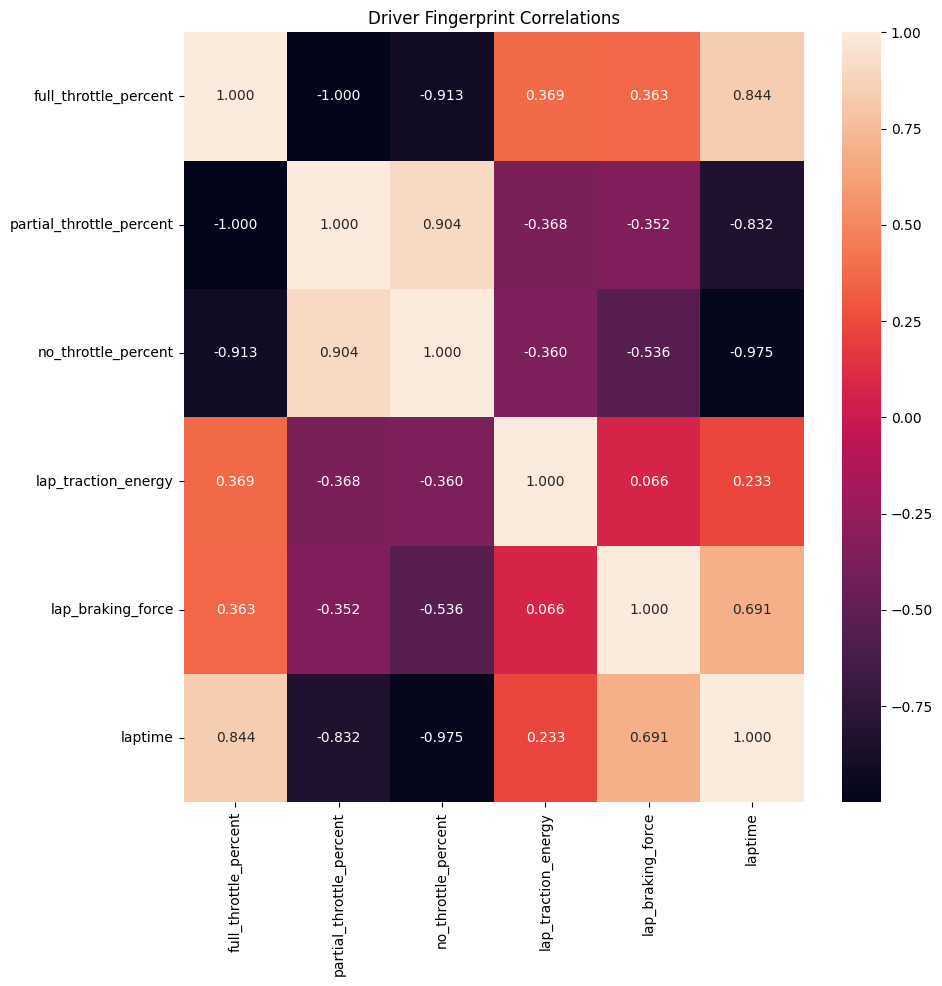

In [25]:
plt.figure(figsize=(10, 10))
sns.heatmap(fingerprint_df.corr(), annot=True, fmt=".3f")
plt.title("Driver Fingerprint Correlations")
plt.show()

## Fin 🏎️ ✨